In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, DenseNet121, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import tensorflow as tf
from glob import glob

In [2]:
def load_data_by_class(data_dir, class_name, label_value, img_size=(128, 128), preprocess=None):
    X, y = [], []
    path = os.path.join(data_dir, class_name)
    for img_file in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_file))
        if img is not None:
            img = cv2.resize(img, img_size)
            if preprocess:
                img = preprocess(img)
            X.append(img)
            y.append(label_value)
    return X, y

In [4]:
# Ensure output directory exists
os.makedirs("output", exist_ok=True)

model_metrics = {}
epochs = 20
custom_epochs = {'VGG16': 10, 'DenseNet121': epochs, 'ResNet50': epochs, 'CNN': epochs}

In [5]:
def load_data_by_class(base_path, subfolder, label):
    data = []
    labels = []
    full_path = os.path.join(base_path, subfolder) if subfolder else base_path
    for img_file in glob(os.path.join(full_path, "**", "*.png"), recursive=True):
        img = cv2.imread(img_file)
        if img is not None:
            img = cv2.resize(img, (128, 128))
            data.append(img)
            labels.append(label)
    return data, labels

spiral_path = "Parkinsons-disease-prediction-using-CNN-main/drawings/Training/spiral"
wave_path = "Parkinsons-disease-prediction-using-CNN-main/drawings/Training/wave"
test_path = "Parkinsons-disease-prediction-using-CNN-main/drawings/testing"


X_train_spiral_healthy, y_train_spiral_healthy = load_data_by_class(spiral_path, "healthy", 0)
X_train_spiral_parkinsons, y_train_spiral_parkinsons = load_data_by_class(spiral_path, "parkinsons", 1)
X_train_wave_healthy, y_train_wave_healthy = load_data_by_class(wave_path, "healthy", 0)
X_train_wave_parkinsons, y_train_wave_parkinsons = load_data_by_class(wave_path, "parkinsons", 1)

X_train = np.array(X_train_spiral_healthy + X_train_spiral_parkinsons + X_train_wave_healthy + X_train_wave_parkinsons, dtype="float32")
y_train = np.array(y_train_spiral_healthy + y_train_spiral_parkinsons + y_train_wave_healthy + y_train_wave_parkinsons)

X_test_healthy, y_test_healthy = load_data_by_class(test_path, "healthy", 0)
X_test_parkinsons, y_test_parkinsons = load_data_by_class(test_path, "parkinsons", 1)
X_test = np.array(X_test_healthy + X_test_parkinsons, dtype="float32")
y_test = np.array(y_test_healthy + y_test_parkinsons)


In [6]:
print(f"Loaded training images: {X_train.shape[0]}")
print(f"Loaded testing images: {X_test.shape[0]}")


Loaded training images: 8402
Loaded testing images: 60


In [7]:
def build_vgg16_model(input_shape):
    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

    # Freeze more layers (freeze all except last 10)
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    predictions = Dense(2, activation='softmax')(x)

    return Model(inputs=base_model.input, outputs=predictions)


In [8]:
def build_densenet_model(input_shape):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(2, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

def build_resnet_model(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(2, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=predictions)

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, SeparableConv2D, BatchNormalization, MaxPooling2D,
    Dropout, GlobalAveragePooling2D, Dense
)

def build_custom_cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    # Block 1
    x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 3
    x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.4)(x)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(2, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs)


In [10]:
model_list = {
    'VGG16': build_vgg16_model((128, 128, 3)),
    'DenseNet121': build_densenet_model((128, 128, 3)),
    'ResNet50': build_resnet_model((128, 128, 3)),
    'CNN': build_custom_cnn_model((128, 128, 3))
}

preprocessors = {
    'VGG16': vgg_preprocess,
    'DenseNet121': densenet_preprocess,
    'ResNet50': resnet_preprocess,
    'CNN': lambda x: x
}

In [11]:
def train_and_evaluate_models():
    for name, model in model_list.items():
        print(f"\nProcessing {name} model...")
        model_path = f"{name}_model.keras"
        prep = preprocessors[name]
        
        # Preprocess data
        X_train_prep, X_test_prep = prep(X_train.astype(np.float32)), prep(X_test.astype(np.float32))
        y_train_cat, y_test_cat = to_categorical(y_train), to_categorical(y_test)

        # Load model if exists, otherwise train
        if os.path.exists(model_path):
            print(f"Loading saved model for {name}...")
            model = load_model(model_path)
        else:
            print(f"Training model for {name}...")
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                X_train_prep, y_train_cat,
                epochs=custom_epochs.get(name, epochs),
                batch_size=32,
                verbose=1,
                validation_split=0.1,
                callbacks=[
                    EarlyStopping(patience=10, restore_best_weights=True),
                    ReduceLROnPlateau(patience=5, factor=0.2)
                ]
            )

            model.save(model_path, save_format='keras')


            # Plot Accuracy (Train & Val Accuracy)
            plt.figure(figsize=(8, 4))
            plt.plot(history.history['accuracy'], label='Train Accuracy')
            plt.plot(history.history['val_accuracy'], label='Val Accuracy')
            plt.title(f"{name} - Accuracy over Epochs")
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.grid(True)
            plt.savefig(f"outputs/{name}_accuracy_epoch.png")
            plt.close()

            # Plot Loss (Train & Val Loss)
            plt.figure(figsize=(8, 4))
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Val Loss')
            plt.title(f"{name} - Loss over Epochs")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid(True)
            plt.savefig(f"outputs/{name}_loss_epoch.png")
            plt.close()

        # Evaluate model
        y_pred = model.predict(X_test_prep)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_test_cat, axis=1)

        acc = accuracy_score(y_true, y_pred_classes)
        f1 = f1_score(y_true, y_pred_classes)
        precision = precision_score(y_true, y_pred_classes)
        recall = recall_score(y_true, y_pred_classes)
        roc = roc_auc_score(y_true, y_pred[:, 1])

        model_metrics[name] = {
            "Accuracy": acc,
            "F1 Score": f1,
            "Precision": precision,
            "Recall": recall,
            "ROC AUC": roc
        }

        print("Classification Report:")
        print(classification_report(y_true, y_pred_classes))

        print("Confusion Matrix:")
        cm = confusion_matrix(y_true, y_pred_classes)
        print(cm)

        # Plot Confusion Matrix
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"outputs/{name}_confusion_matrix.png")
        plt.close()

        # Plot ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_pred[:, 1])
        plt.figure()
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc:.2f})")
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend(loc="lower right")
        plt.savefig(f"outputs/{name}_roc_curve.png")
        plt.close()

train_and_evaluate_models()



Processing VGG16 model...
Loading saved model for VGG16...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        30
           1       0.90      0.93      0.92        30

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60

Confusion Matrix:
[[27  3]
 [ 2 28]]

Processing DenseNet121 model...
Loading saved model for DenseNet121...
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        30
           1       0.92      0.80      0.86        30

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60

Confusion Matrix:
[[28  2]
 [ 6 24]]

Processing ResNet50 m

In [12]:
print("\n\n Final Model Evaluation Summary:\n")
df_metrics = pd.DataFrame(model_metrics).T
print(df_metrics.round(2))




 Final Model Evaluation Summary:

             Accuracy  F1 Score  Precision  Recall  ROC AUC
VGG16            0.92      0.92       0.90    0.93     0.96
DenseNet121      0.87      0.86       0.92    0.80     0.95
ResNet50         0.78      0.79       0.77    0.80     0.89
CNN              0.60      0.66       0.57    0.77     0.63


<Figure size 1000x600 with 0 Axes>

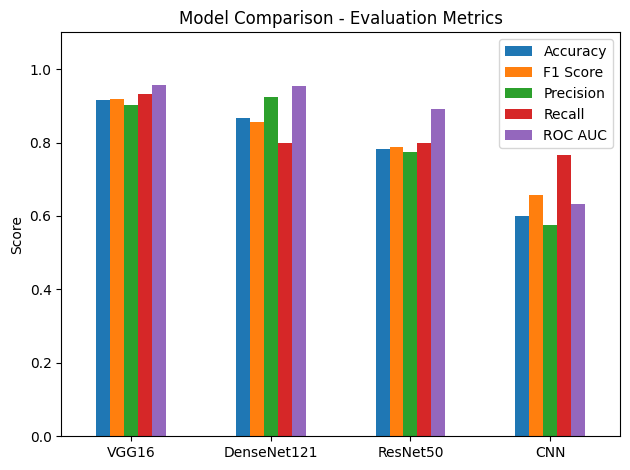

In [13]:
plt.figure(figsize=(10, 6))
df_metrics[['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']].plot(kind='bar')
plt.title("Model Comparison - Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/model_metrics_comparison.png")
plt.show()

In [ ]:
# Validation Data

In [97]:
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf

# Load validation dataset (resize to 224x224 or 128x128 as needed)
val_dir = 'Parkinsons-disease-prediction-using-CNN-main/validation'

validation_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),  # or (224, 224) depending on your model
    batch_size=32,
    label_mode='int',  # This gives integer labels
    shuffle=False
)

# Extract images and labels from tf.data.Dataset
X_val = []
y_val = []
for images, labels in validation_dataset:
    X_val.extend(images.numpy())
    y_val.extend(labels.numpy())

X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"Validation images loaded: {len(X_val)}")


Found 1034 files belonging to 2 classes.
Validation images loaded: 1034


In [98]:

# Resize validation images to match model input shape (128x128x3)
def resize_128(imgs):
    return tf.image.resize(imgs, [128, 128]).numpy()

# Convert labels to categorical format
y_val_cat = to_categorical(y_val)

# Directory for saving output plots
os.makedirs("outputs2", exist_ok=True)

model_metrics = {}
model_lists = ["VGG16", "ResNet50", "CNN"]  

def validate_models():
    for name in model_lists:
        model_path = f"{name}_model.keras"
        if not os.path.exists(model_path):
            print(f"Model {name} not found. Skipping.")
            continue

        print(f"\nValidating {name}...")
        model = load_model(model_path)

        # Resize validation images
        X_val_prep = resize_128(X_val.astype(np.float32))

        # Predict
        y_pred = model.predict(X_val_prep)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_val_cat, axis=1)

        # Metrics calculation
        acc = accuracy_score(y_true, y_pred_classes)
        f1 = f1_score(y_true, y_pred_classes)
        precision = precision_score(y_true, y_pred_classes)
        recall = recall_score(y_true, y_pred_classes)
        roc = roc_auc_score(y_true, y_pred[:, 1])

        model_metrics[name] = {
            "Accuracy": acc,
            "F1 Score": f1,
            "Precision": precision,
            "Recall": recall,
            "ROC AUC": roc
        }

        print("Classification Report:")
        print(classification_report(y_true, y_pred_classes))

        cm = confusion_matrix(y_true, y_pred_classes)
        print("Confusion Matrix:")
        print(cm)

        # Confusion matrix plot
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"outputs2/{name}_validation_confusion_matrix.png")
        plt.close()

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_pred[:, 1])
        plt.figure()
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc:.2f})")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend(loc="lower right")
        plt.savefig(f"outputs2/{name}_validation_roc_curve.png")
        plt.close()

# Run validation
validate_models()

# Final summary
print("\n Final Model Validation Scores:")
for model, metrics in model_metrics.items():
    print(f"\n{model} Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.2f}")  


Validating VGG16...
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 833ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86       520
           1       0.82      0.93      0.87       514

    accuracy                           0.86      1034
   macro avg       0.87      0.86      0.86      1034
weighted avg       0.87      0.86      0.86      1034

Confusion Matrix:
[[416 104]
 [ 36 478]]

Validating ResNet50...
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 467ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       520
           1       0.73      0.70      0.72       514

    accuracy                           0.72      1034
   macro avg       0.72      0.72      0.72      1034
weighted avg       0.72      0.72      0.72      1034

Confusion Matrix:
[[389 131]
 [155 359]]

Validating CNN...
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step
Classification Report:
      

In [99]:
import numpy as np
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# Load validation dataset


val_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False,
    label_mode='int'  # must be 'int' for classification_report
)
# Normalize images like during training
normalization_layer = tf.keras.layers.Rescaling(1./255)
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Extract all images and labels
X_val = []
y_val = []

for images, labels in val_dataset:
    X_val.append(images.numpy())
    y_val.append(labels.numpy())

X_val = np.concatenate(X_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

print(f"Validation set size: {X_val.shape}, Labels shape: {y_val.shape}")


Found 1034 files belonging to 2 classes.
Validation set size: (1034, 128, 128, 3), Labels shape: (1034,)


In [100]:
# Load your trained DenseNet model
from tensorflow.keras.models import load_model
model = load_model("DenseNet121_model.keras")  # update path

# Predict
y_pred_probs = model.predict(X_val, batch_size=32)
y_pred_classes = np.argmax(y_pred_probs, axis=1)


33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 589ms/step


In [101]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification Report with custom labels
print("Classification Report:")
print(classification_report(y_val, y_pred_classes, target_names=["Healthy", "Parkinson's"]))

# ROC AUC
roc_auc = roc_auc_score(y_val, y_pred_probs[:, 1])  # y_pred_probs is the predicted probabilities
print(f"ROC AUC Score: {roc_auc:.2f}")

# ROC Curve Plot
fpr, tpr, _ = roc_curve(y_val_cat[:, 1], y_pred_probs[:, 1])  # y_val_cat[:, 1] for positive class (Parkinson's)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - AUC = {roc_auc:.2f}")
plt.legend(loc="lower right")
plt.savefig(f"outputs2/densenet121_validation_roc_curve.png")
plt.close()

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Parkinson's"], yticklabels=["Healthy", "Parkinson's"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"outputs2/densenet121_validation_Confusion_matrix.png")  
plt.close()

Confusion Matrix:
[[369 151]
 [ 47 467]]
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.89      0.71      0.79       520
 Parkinson's       0.76      0.91      0.83       514

    accuracy                           0.81      1034
   macro avg       0.82      0.81      0.81      1034
weighted avg       0.82      0.81      0.81      1034

ROC AUC Score: 0.92


In [102]:
densenet_metrics = {
    "Accuracy": 0.81,  # replace with real values from previous DenseNet validation
    "F1 Score": 0.81,
    "Precision": 0.82,
    "Recall": 0.81,
    "ROC AUC": 0.92
}
model_metrics["DenseNet121"] = densenet_metrics

# Summary
print("\nFinal Model Validation Metrics:")
summary_df = pd.DataFrame(model_metrics).T.round(2)
print(summary_df.to_string())


Final Model Validation Metrics:
             Accuracy  F1 Score  Precision  Recall  ROC AUC
VGG16            0.86      0.87       0.82    0.93     0.94
ResNet50         0.72      0.72       0.73    0.70     0.79
CNN              0.62      0.68       0.59    0.80     0.63
DenseNet121      0.81      0.81       0.82    0.81     0.92


<Figure size 1000x600 with 0 Axes>

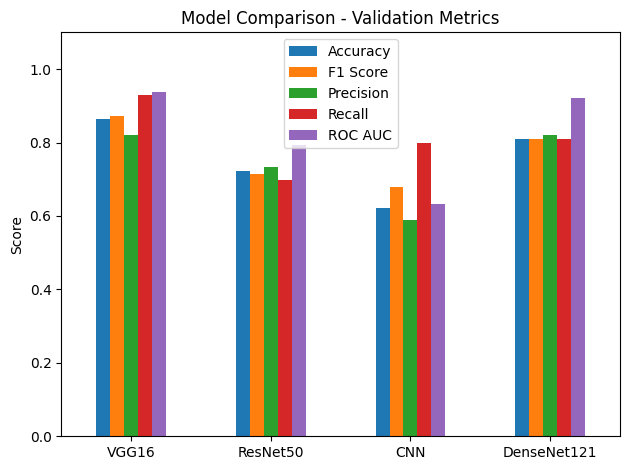

In [75]:
plt.figure(figsize=(10, 6))
summary_df[['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']].plot(kind='bar')
plt.title("Model Comparison - Validation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs2/model_metrics_comparison.png")
plt.show()

In [ ]:
import subprocess

# Replace 'app.py' with the name of your Streamlit script
subprocess.run(["streamlit", "run", "Streamlit_validator_parkisons.py"])